# Director Skill Sets Table 7 - Appointments only

In [1]:
import pandas_datareader.data as web #to collect data
import datetime as dt #to specify start and end dates

# import yfinance as yf

import eventstudy as es
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d
%matplotlib inline
import seaborn as sns

import scipy.stats as stats
from scipy.stats.mstats import winsorize
from scipy.spatial.distance import cdist


from sklearn.neighbors import NearestNeighbors

import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

from sklearn.preprocessing import StandardScaler

from patsy import dmatrices
from tqdm.notebook import tqdm
tqdm.pandas()

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] CAPM CAR\car_output4"
output_folder_path = "analysis_outputs"
# pca_input_folder_path = rf"..\..\..\[IN USE] Rookie Directors\[1.5] Director Skills PCA\director_skills_pca"
firm_input_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[2] Firm Level Wrangling\Firm level Iterative\Firm Lev + Fin\City level\city_lev_output"
filtering_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_filtering"
supporting_folder_path = "supporting_datafiles"

In [3]:
dirFirm00 = pd.read_pickle(rf"{import_folder_path}\Director Level_MF_CAR.pkl")
dirFirm00 = dirFirm00.loc[ dirFirm00["date_source"] == "Appointment Date"].reset_index(drop = True)

# pca = pd.read_pickle(rf"{pca_input_folder_path}\Main_Director_COMPLETE_PCA.pkl")
firm = pd.read_pickle(rf"{firm_input_folder_path}\Main_Firm_COMPLETE.pkl")

In [4]:
# pca_col = [
#     "Person Code", "AsOnDate", "Symbol",
#     "SkillsetIndex", "SkillsetGeneralistDummy",
#     "PC1_FactorScore", "PC1_FactorScore_Standardised"
# ]

# pca2 = pca[pca_col].copy()
# dirFirm00 = dirFirm0.merge(pca2, on = ["Person Code", "AsOnDate", "Symbol"], how = "left")

In [5]:
firm_col = [
    "AsOnDate", "Symbol",

    "PercentWomenDir", "PercentBusyDir",
    "LnBoardSize", "PercentIndep",
    "Promoters_percent", "NonpromoterInstitutions_percent", "RD to Assets",
    "ln_marcap", "ln_rdtoassets", "Debt to equity ratio", # control variables
    
    "FamilyOwnedFamilyCeoChair25", "promoterholding25", "HasFamilyChairmanAndCEO",
]

firm2 = firm[firm_col].copy()
dirFirm = dirFirm00.merge(firm2, on = ["AsOnDate", "Symbol"], how = "left")

In [6]:
# dirFirm data wrangling if any:
dirFirm["Year of Study"] = [x.year for x in dirFirm["Date of Study"]]

dirFirm = dirFirm.drop_duplicates(subset = ["Person Code", "Company", "Date of Study"]).reset_index(drop = True)

dirFirm["ln_dirage"] = np.log(dirFirm["Age"] + 1).astype("float")
dirFirm["ln_directorships"] = np.log((dirFirm["CompCountCurrTotalAB"] - 1) + 1).astype("float")

In [7]:
dirFirm.replace([np.inf, -np.inf], pd.NA, inplace = True)

# PSM

## Verifying and removing those rows with no control data points

In [8]:
# Sample constraints ---> govtdummy==0 & findummy==0 & asonyear>2012
# dirFirm.columns.to_list()

In [10]:
dirFirm["IsDualityChairmanMD"] = dirFirm["IsDualityChairmanMD"].astype(int)


dirFirm["NIC_1digit"] = dirFirm["NIC code"].dropna().apply(lambda x: x[0:1])
dirFirm["NIC_1digit"] = dirFirm["NIC_1digit"]

dirFirm.loc[dirFirm["RD to Assets"] == 0, "ln_rdtoassets"] = 0

psmSample = dirFirm.loc[ (dirFirm["Year of Study"] >= 2013) 
    & (dirFirm["govtdummy"] == 0) & (dirFirm["findummy"] == 0) ].copy()
#.dropna(subset = controlVars).dropna(subset = dependentVar).copy()

# psmSample["DummySum"] = psmSample["IsRookie"] + psmSample["IsNonRookie"]
psmSample["DummySumIndep"] = psmSample["IsRookieIndep"] + psmSample["IsNonRookieIndep"]

# psmSampleAll = psmSample.loc[ psmSample["DummySum"] == 1 ].reset_index(drop = True)
# psmSampleAll = psmSampleAll.loc[ ~psmSampleAll.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

psmSampleIndep = psmSample.loc[ psmSample["DummySumIndep"] == 1 ].reset_index(drop = True)
# psmSampleIndep = psmSampleIndep.loc[ ~psmSampleIndep.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

## CAR windsorization

       winsorised_120CAR3  nonwinsorised_120CAR3
count         6556.000000            6556.000000
mean            -0.000853              -0.003559
std              0.067594               0.090528
min             -0.156707              -2.647100
25%             -0.038282              -0.038282
50%             -0.004704              -0.004704
75%              0.031576               0.031576
max              0.623639               0.623639


Top values and their count:  nonwinsorised_120CAR3
0.310901    1
0.328314    1
0.328676    2
0.346248    1
0.359586    1
0.368255    1
0.394401    1
0.522075    1
0.579376    1
0.623639    1
Name: count, dtype: int64





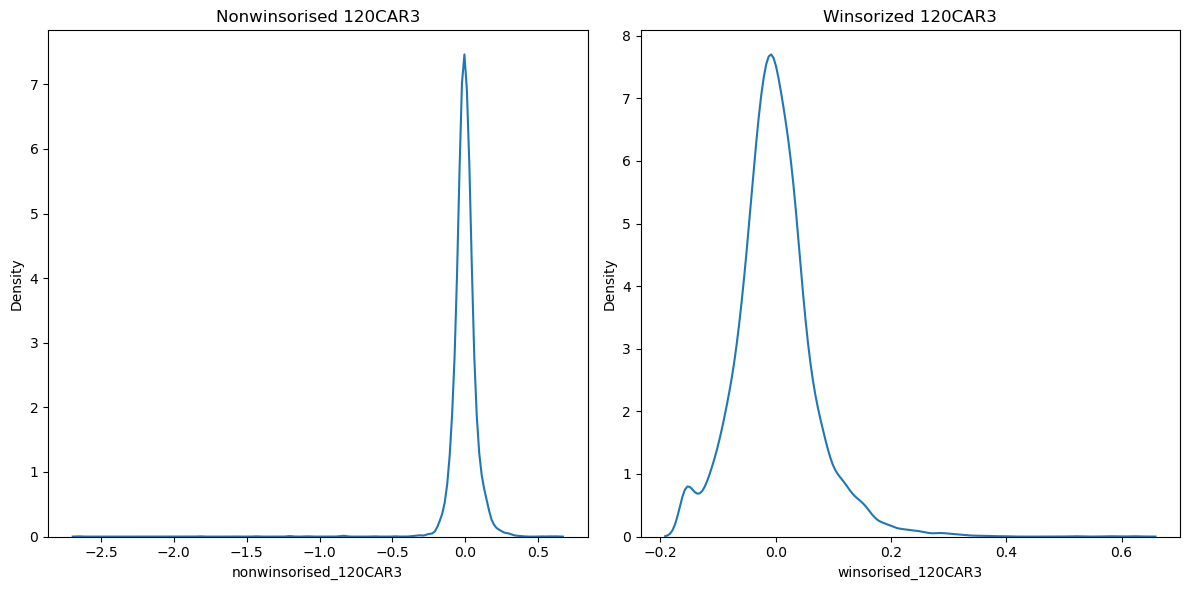

       winsorised_120CAR5  nonwinsorised_120CAR5
count         6554.000000            6554.000000
mean            -0.050754              -0.053874
std              0.085477               0.112473
min             -0.247122              -3.348903
25%             -0.096742              -0.096742
50%             -0.054877              -0.054877
75%             -0.013624              -0.013624
max              0.868369               0.868369


Top values and their count:  nonwinsorised_120CAR5
0.373649    1
0.382215    1
0.382607    1
0.445690    2
0.454120    1
0.553789    1
0.558098    1
0.620251    1
0.668784    1
0.868369    1
Name: count, dtype: int64





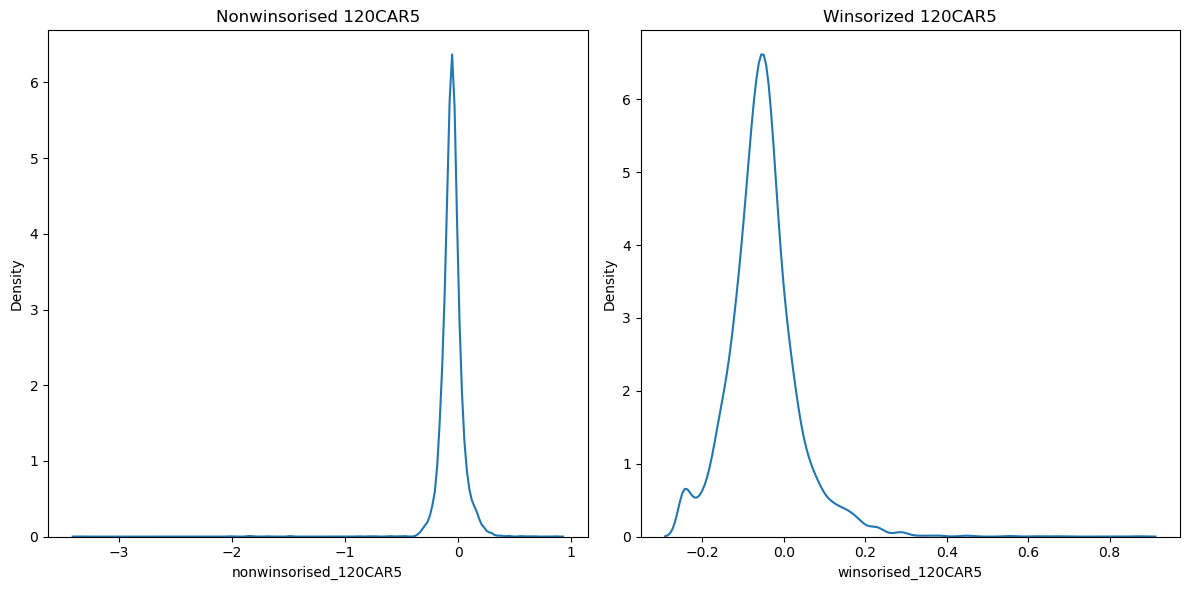

       winsorised_120CAR7  nonwinsorised_120CAR7
count         6552.000000            6552.000000
mean            -0.099062              -0.102390
std              0.102760               0.129079
min             -0.331273              -3.842644
25%             -0.158987              -0.158987
50%             -0.102371              -0.102371
75%             -0.050861              -0.050861
max              1.328174               1.328174


Top values and their count:  nonwinsorised_120CAR7
0.372698    1
0.392328    1
0.399700    1
0.417270    2
0.435462    1
0.502097    1
0.526530    1
0.539612    1
0.581657    2
1.328174    1
Name: count, dtype: int64





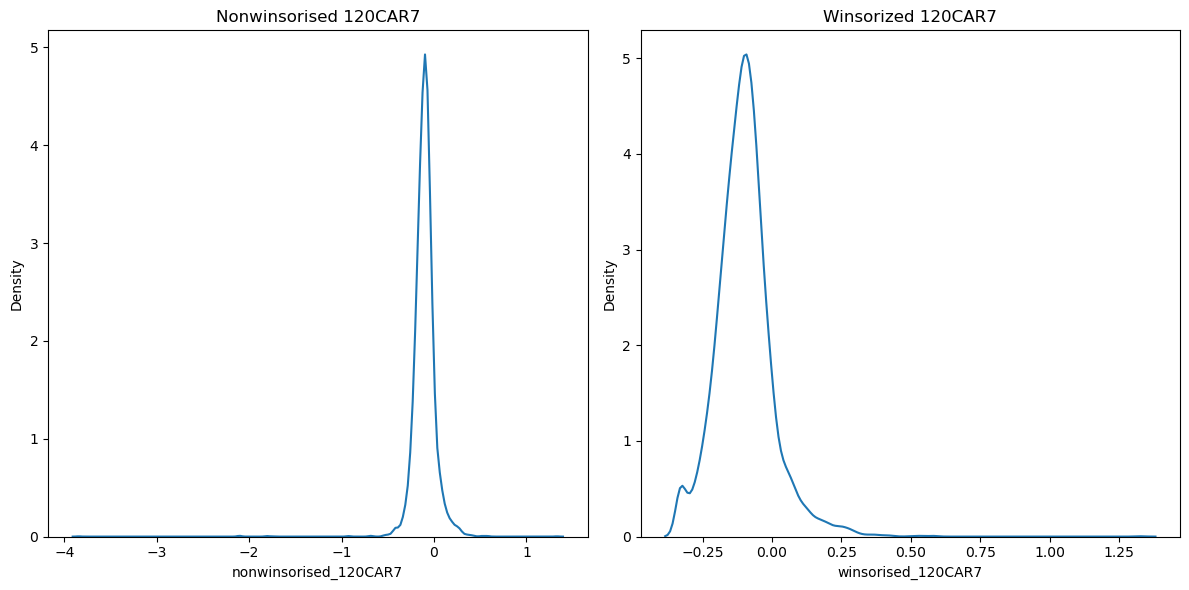

       winsorised_120CAR11  nonwinsorised_120CAR11
count          6543.000000             6543.000000
mean             -0.193413               -0.197514
std               0.135579                0.168738
min              -0.485359               -4.078573
25%              -0.273393               -0.273393
50%              -0.202268               -0.202268
75%              -0.126752               -0.126752
max               2.014721                2.014721


Top values and their count:  nonwinsorised_120CAR11
0.419914    1
0.427592    1
0.436032    2
0.468507    1
0.502445    1
0.503005    1
0.508223    1
0.516500    1
0.696832    1
2.014721    1
Name: count, dtype: int64





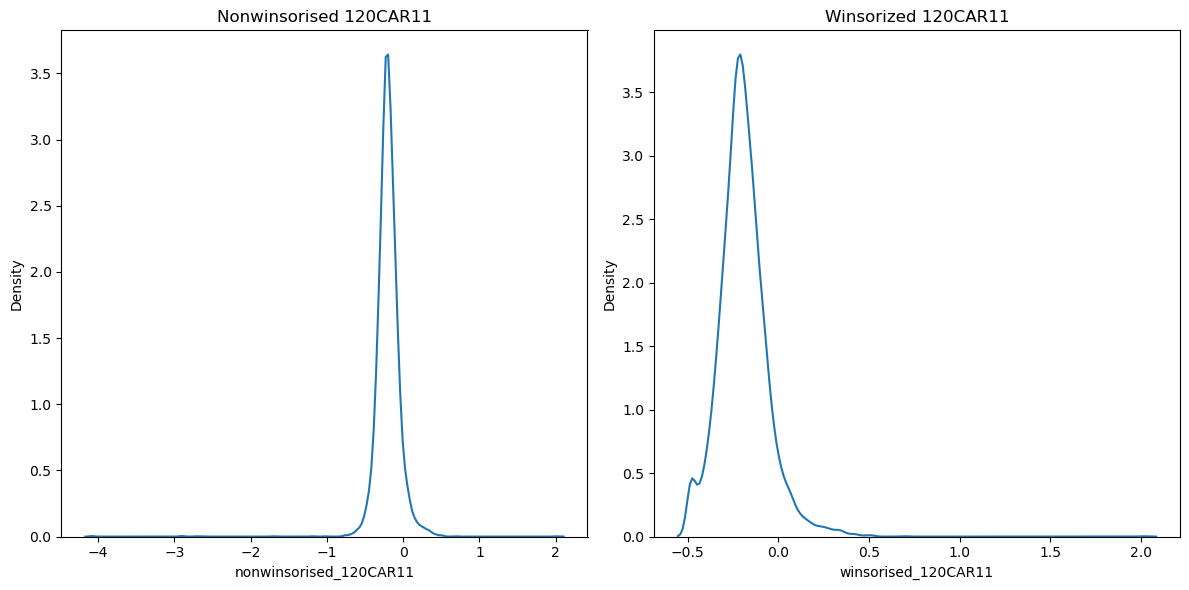

       winsorised_150CAR3  nonwinsorised_150CAR3
count         6528.000000            6528.000000
mean            -0.000829              -0.003526
std              0.067355               0.091913
min             -0.154001              -3.221861
25%             -0.038938              -0.038938
50%             -0.004631              -0.004631
75%              0.031297               0.031297
max              0.632025               0.632025


Top values and their count:  nonwinsorised_150CAR3
0.317981    1
0.319358    1
0.323994    2
0.347946    1
0.361189    1
0.371079    1
0.393755    1
0.523193    1
0.583729    1
0.632025    1
Name: count, dtype: int64





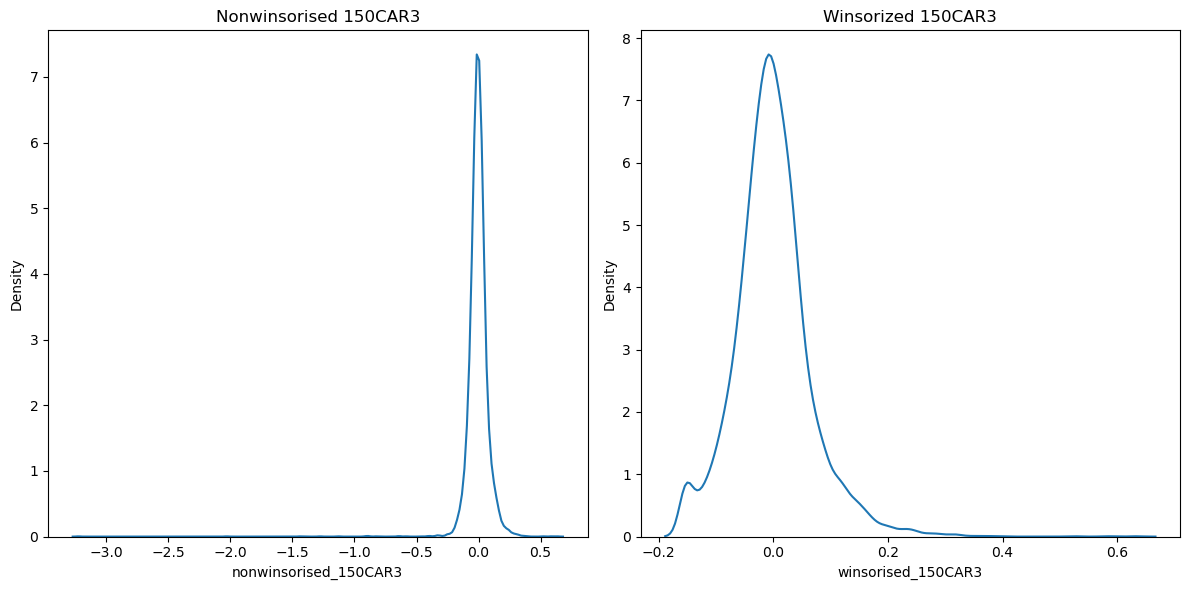

       winsorised_150CAR5  nonwinsorised_150CAR5
count         6526.000000            6526.000000
mean            -0.050868              -0.054002
std              0.085418               0.115795
min             -0.247588              -4.324328
25%             -0.097279              -0.097279
50%             -0.054744              -0.054744
75%             -0.014183              -0.014183
max              0.872016               0.872016


Top values and their count:  nonwinsorised_150CAR5
0.375354    1
0.379324    1
0.379363    1
0.437972    2
0.454583    1
0.554900    1
0.571805    1
0.638748    1
0.650069    1
0.872016    1
Name: count, dtype: int64





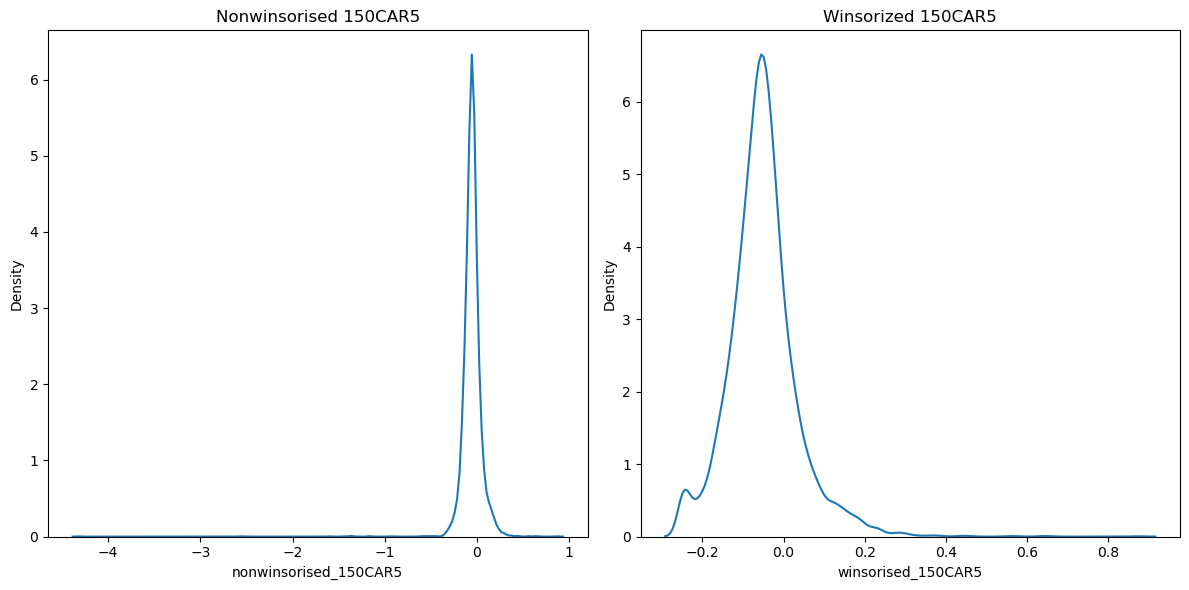

       winsorised_150CAR7  nonwinsorised_150CAR7
count         6524.000000            6524.000000
mean            -0.099050              -0.102306
std              0.102561               0.127637
min             -0.326558              -3.665430
25%             -0.158779              -0.158779
50%             -0.102370              -0.102370
75%             -0.051787              -0.051787
max              1.332583               1.332583


Top values and their count:  nonwinsorised_150CAR7
0.373575    1
0.393897    1
0.404041    1
0.414364    2
0.435668    1
0.503294    1
0.523505    1
0.557947    1
0.577873    2
1.332583    1
Name: count, dtype: int64





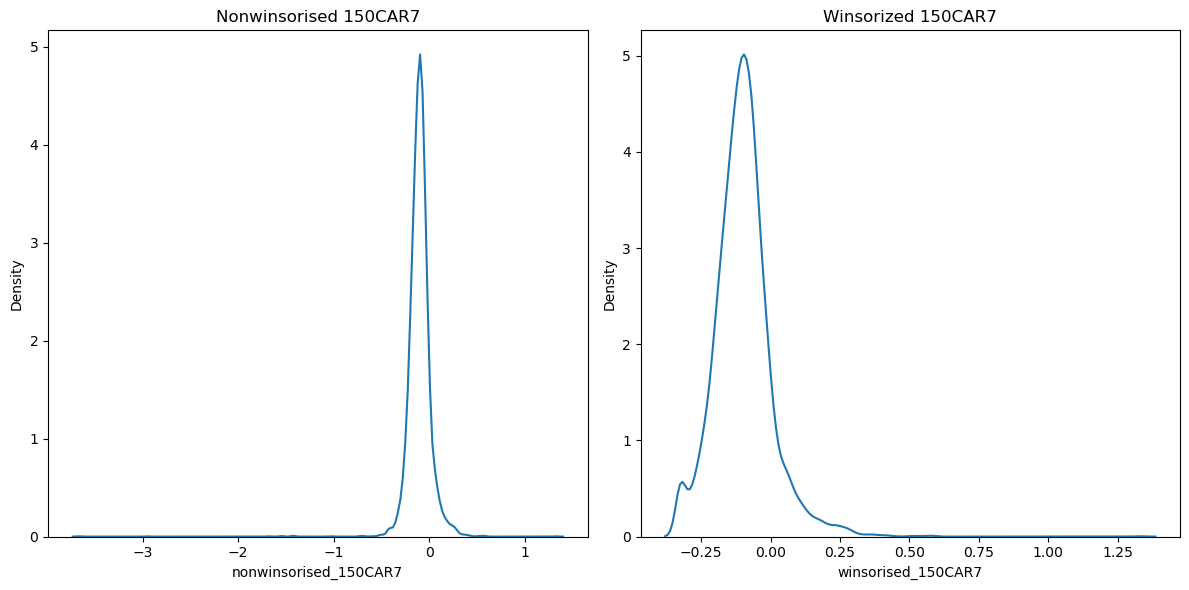

       winsorised_150CAR11  nonwinsorised_150CAR11
count          6515.000000             6515.000000
mean             -0.193440               -0.197300
std               0.135592                0.165719
min              -0.485541               -4.800508
25%              -0.272829               -0.272829
50%              -0.203339               -0.203339
75%              -0.126129               -0.126129
max               2.019356                2.019356


Top values and their count:  nonwinsorised_150CAR11
0.420683    1
0.430561    1
0.436592    2
0.452048    1
0.473047    1
0.497212    1
0.508292    1
0.509215    1
0.717770    1
2.019356    1
Name: count, dtype: int64





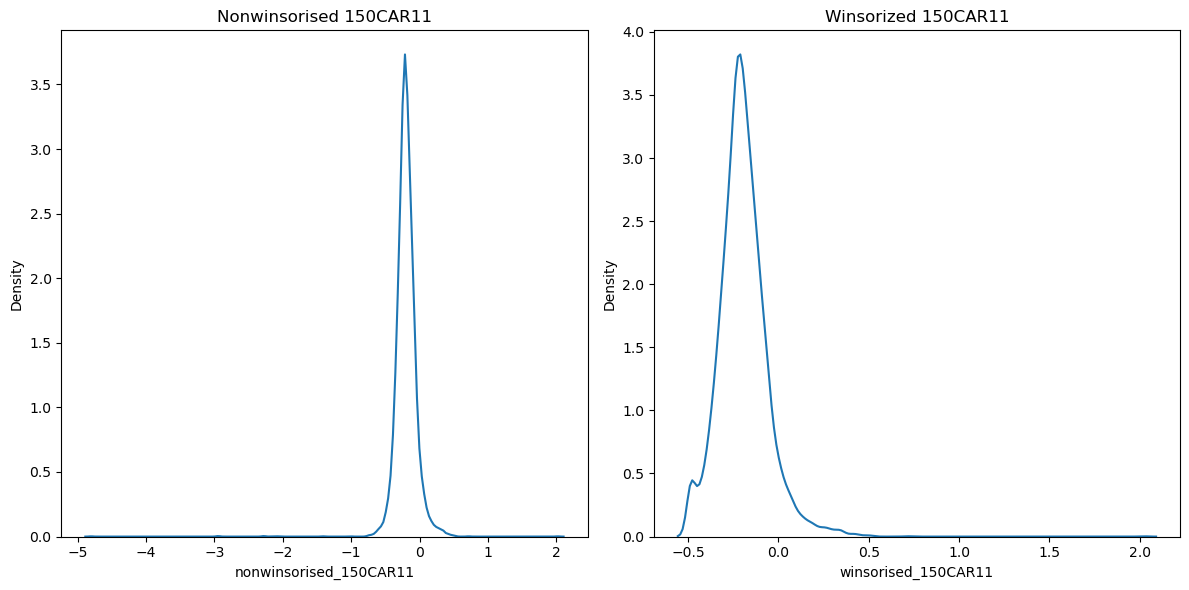

       winsorised_180CAR3  nonwinsorised_180CAR3
count         6492.000000            6492.000000
mean            -0.000825              -0.003085
std              0.067506               0.085901
min             -0.155801              -2.668733
25%             -0.038875              -0.038875
50%             -0.004315              -0.004315
75%              0.031272               0.031272
max              0.640422               0.640422


Top values and their count:  nonwinsorised_180CAR3
0.316501    1
0.317497    1
0.321673    2
0.345768    1
0.358965    1
0.374823    1
0.392285    1
0.519407    1
0.584829    1
0.640422    1
Name: count, dtype: int64





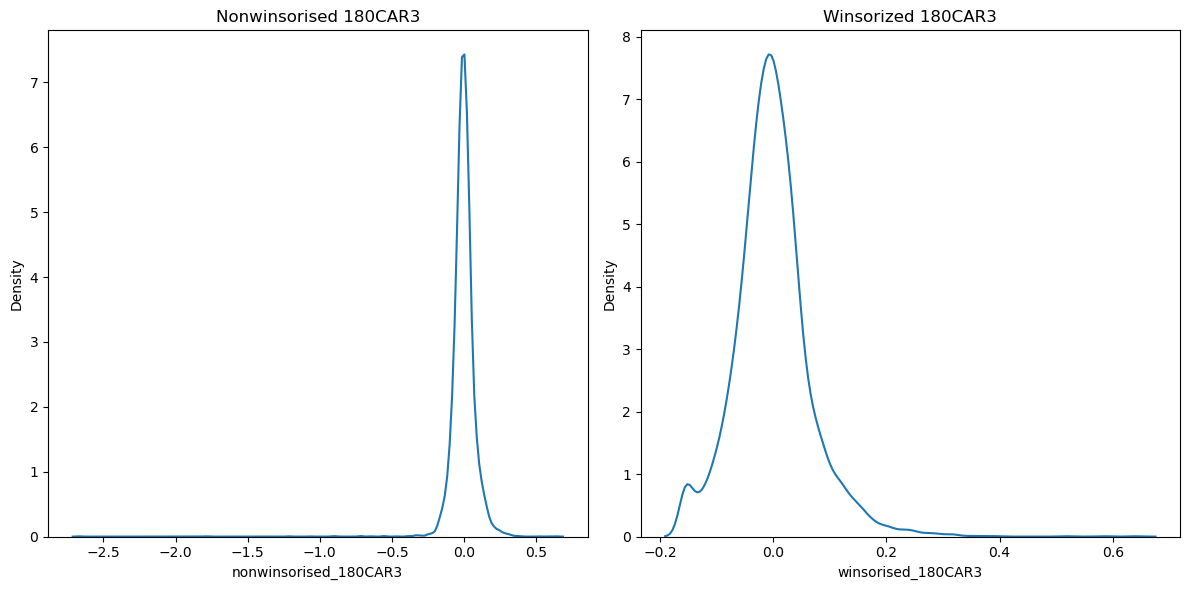

       winsorised_180CAR5  nonwinsorised_180CAR5
count         6490.000000            6490.000000
mean            -0.050747              -0.053473
std              0.085455               0.108413
min             -0.242443              -3.613317
25%             -0.097223              -0.097223
50%             -0.055077              -0.055077
75%             -0.013217              -0.013217
max              0.872663               0.872663


Top values and their count:  nonwinsorised_180CAR5
0.378978    1
0.379967    1
0.387180    1
0.436565    2
0.462422    1
0.551085    1
0.586025    1
0.654920    1
0.673014    1
0.872663    1
Name: count, dtype: int64





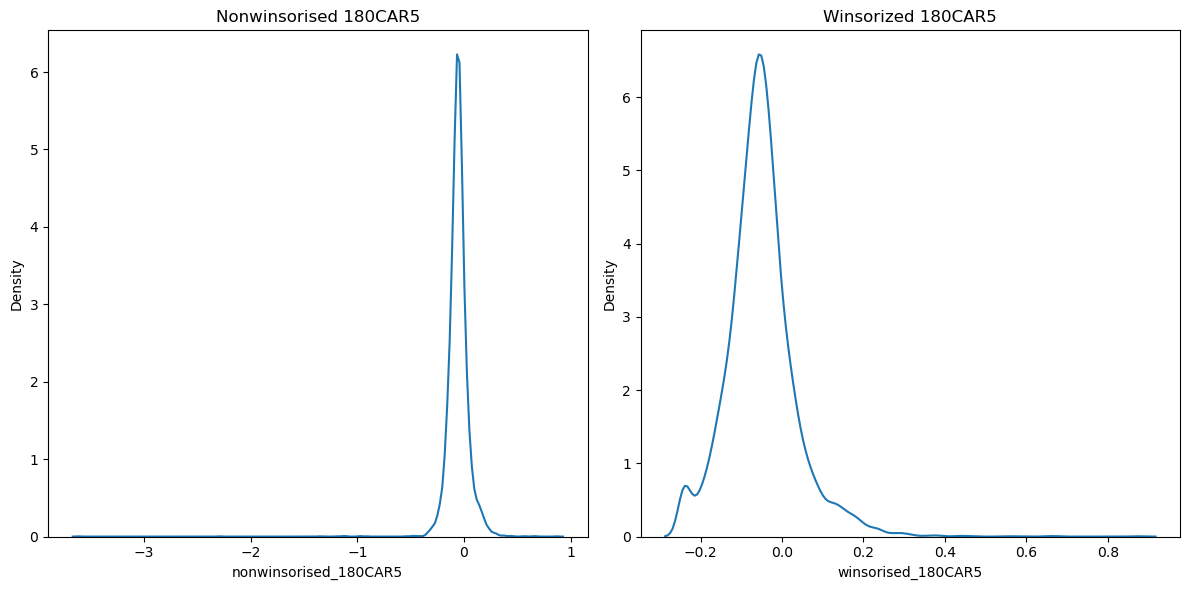

       winsorised_180CAR7  nonwinsorised_180CAR7
count         6488.000000            6488.000000
mean            -0.098939              -0.101744
std              0.102757               0.121797
min             -0.326843              -3.054632
25%             -0.158106              -0.158106
50%             -0.103334              -0.103334
75%             -0.050986              -0.050986
max              1.333720               1.333720


Top values and their count:  nonwinsorised_180CAR7
0.380240    1
0.397468    1
0.402607    1
0.412262    2
0.443512    1
0.499881    1
0.531185    1
0.573549    1
0.575282    2
1.333720    1
Name: count, dtype: int64





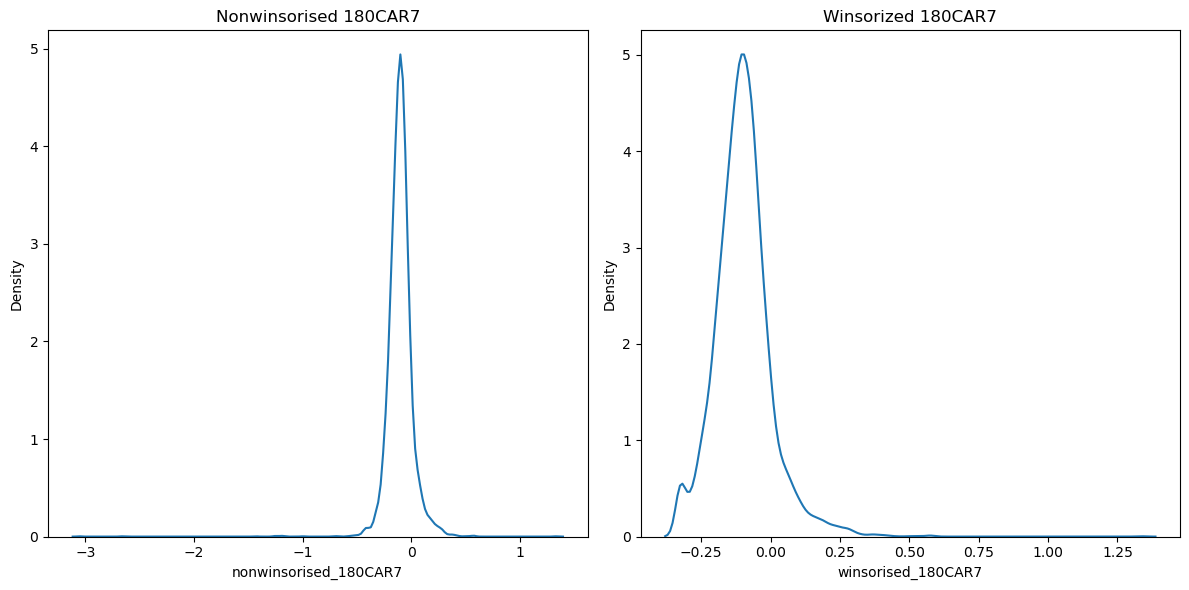

       winsorised_180CAR11  nonwinsorised_180CAR11
count          6479.000000             6479.000000
mean             -0.193262               -0.196535
std               0.135930                0.157611
min              -0.485034               -4.039726
25%              -0.272500               -0.272500
50%              -0.203944               -0.203944
75%              -0.125876               -0.125876
max               2.020638                2.020638


Top values and their count:  nonwinsorised_180CAR11
0.423077    1
0.430860    1
0.438797    2
0.469372    1
0.470607    1
0.505119    1
0.509622    1
0.512421    1
0.732353    1
2.020638    1
Name: count, dtype: int64





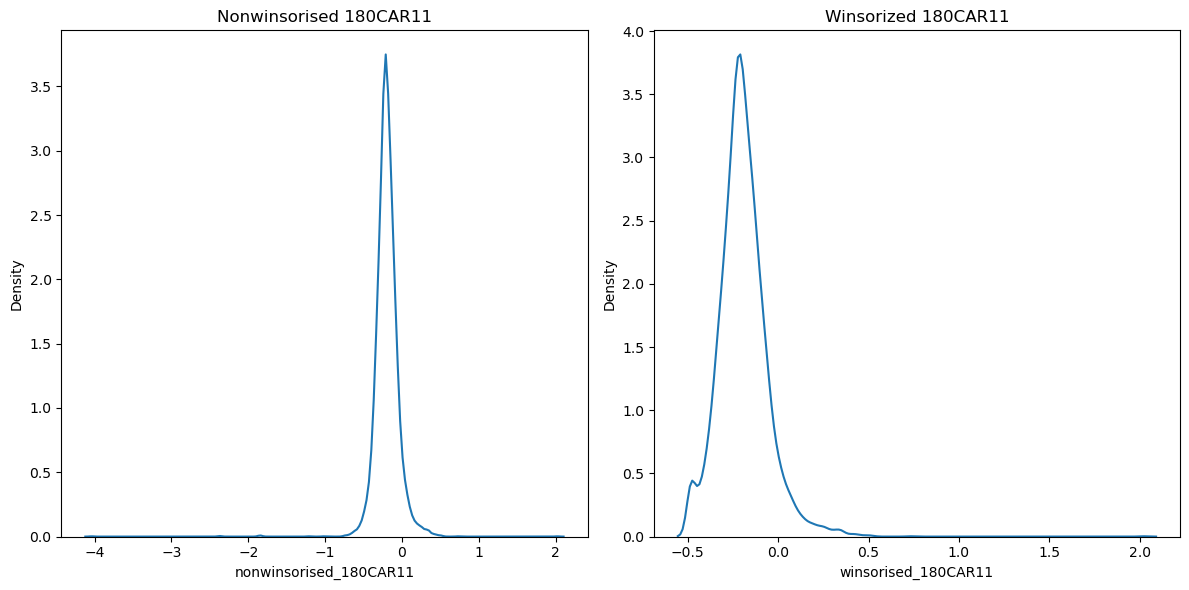

       winsorised_210CAR3  nonwinsorised_210CAR3
count         6464.000000            6464.000000
mean            -0.000524              -0.002485
std              0.067448               0.080974
min             -0.152697              -2.206899
25%             -0.039351              -0.039351
50%             -0.004099              -0.004099
75%              0.031684               0.031684
max              0.632447               0.632447


Top values and their count:  nonwinsorised_210CAR3
0.311142    1
0.315092    1
0.319827    2
0.342963    1
0.360899    1
0.376752    1
0.386649    1
0.519152    1
0.585313    1
0.632447    1
Name: count, dtype: int64





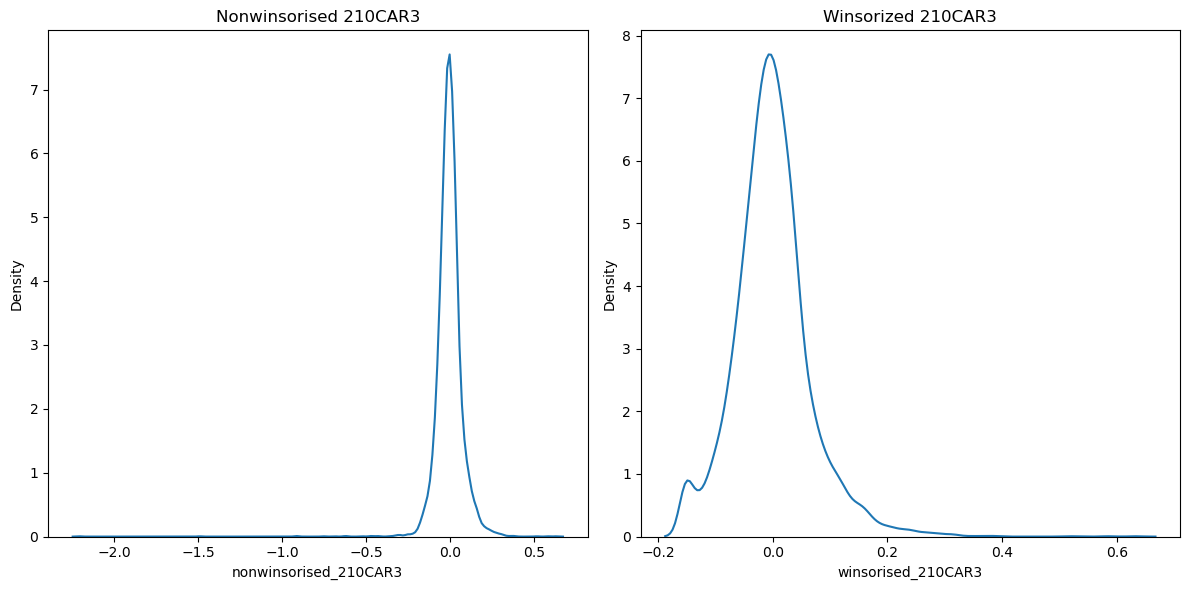

       winsorised_210CAR5  nonwinsorised_210CAR5
count         6462.000000            6462.000000
mean            -0.050376              -0.052643
std              0.085345               0.101547
min             -0.239757              -2.921795
25%             -0.097285              -0.097285
50%             -0.054775              -0.054775
75%             -0.012197              -0.012197
max              0.872740               0.872740


Top values and their count:  nonwinsorised_210CAR5
0.377313    1
0.379482    1
0.387604    1
0.434784    2
0.461547    1
0.550790    1
0.571973    1
0.668294    1
0.671156    1
0.872740    1
Name: count, dtype: int64





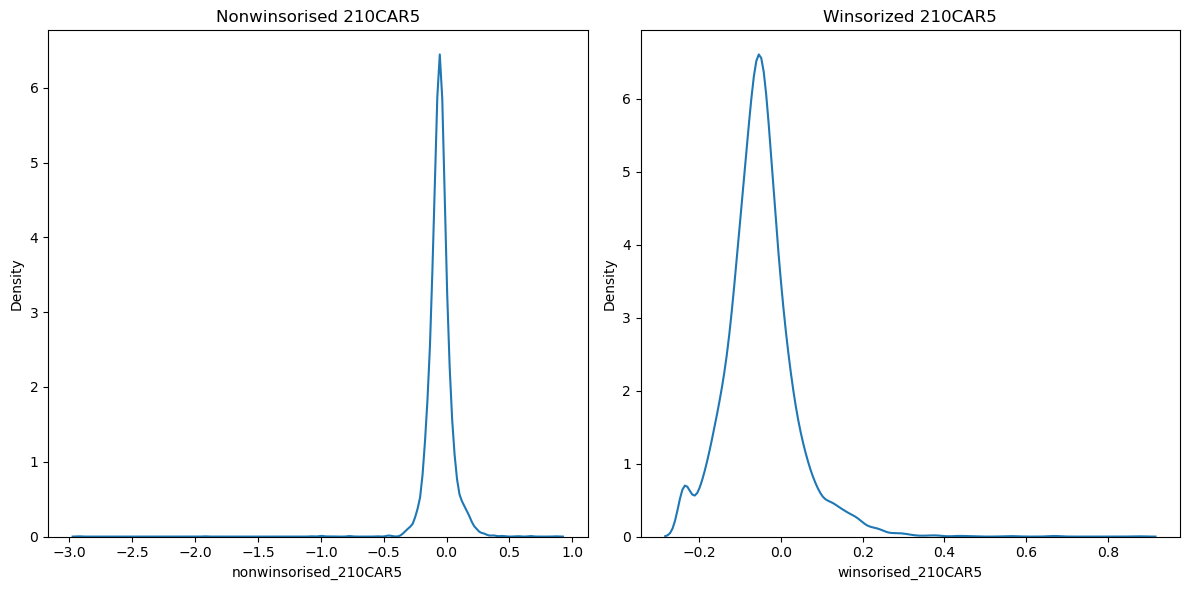

       winsorised_210CAR7  nonwinsorised_210CAR7
count         6460.000000            6460.000000
mean            -0.098560              -0.100993
std              0.102675               0.116581
min             -0.323965              -2.508900
25%             -0.158454              -0.158454
50%             -0.102717              -0.102717
75%             -0.050407              -0.050407
max              1.334236               1.334236


Top values and their count:  nonwinsorised_210CAR7
0.383689    1
0.399452    1
0.407529    1
0.412619    2
0.442582    1
0.500137    1
0.531589    1
0.573416    2
0.590296    1
1.334236    1
Name: count, dtype: int64





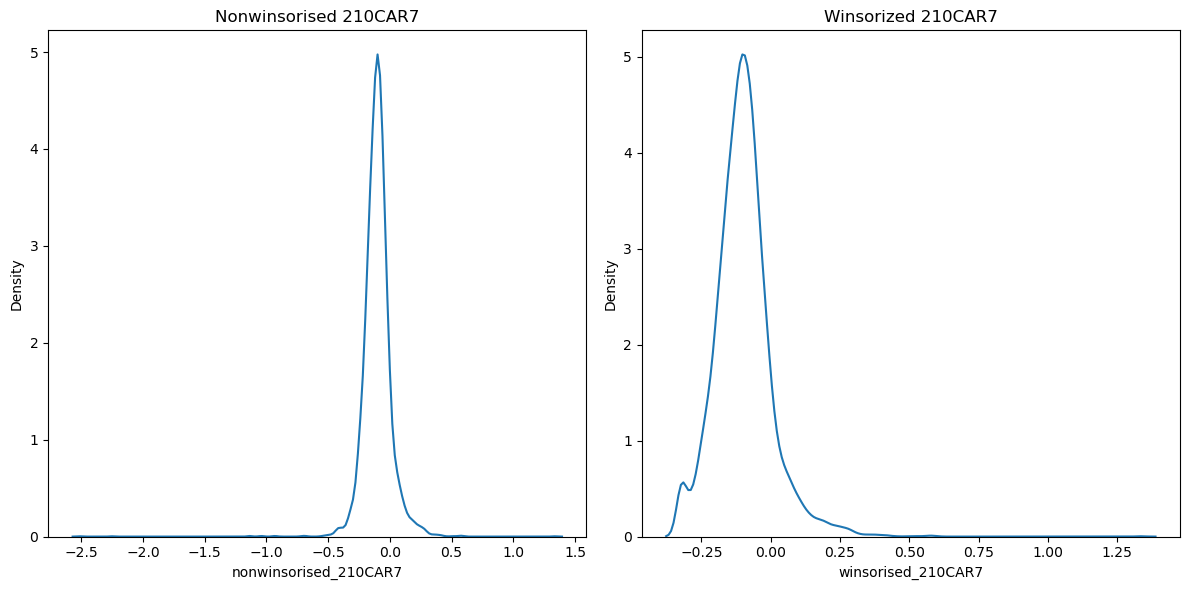

       winsorised_210CAR11  nonwinsorised_210CAR11
count          6451.000000             6451.000000
mean             -0.192825               -0.195545
std               0.135886                0.151146
min              -0.484373               -3.275796
25%              -0.271843               -0.271843
50%              -0.203540               -0.203540
75%              -0.125842               -0.125842
max               2.021285                2.021285


Top values and their count:  nonwinsorised_210CAR11
0.414654    1
0.437797    1
0.441406    2
0.467179    1
0.475296    1
0.490545    1
0.509975    1
0.523915    1
0.737727    1
2.021285    1
Name: count, dtype: int64





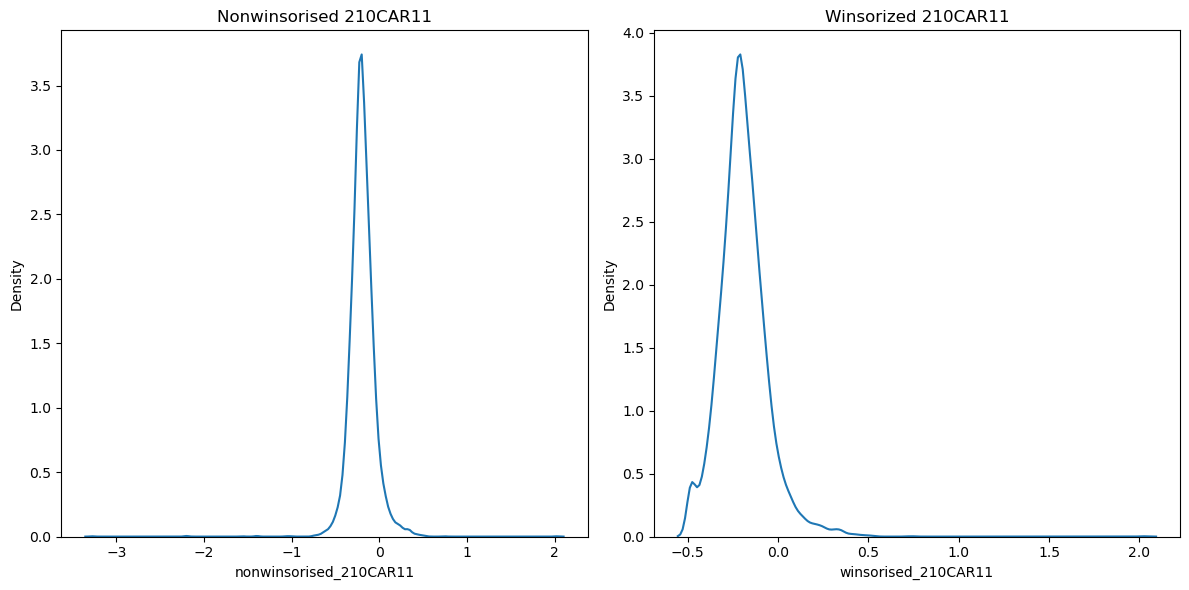

In [11]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    print("\n\nTop values and their count: ", (sample[f"nonwinsorised_{variable}"].value_counts().sort_index().tail(n=10)))
    print("\n\n")
    
    # Graphs
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

for car in carCol:
    psmSampleIndep[car] = winsorize_output(psmSampleIndep, car, [0.01, 0.01])

In [12]:
# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "PC1_FactorScore_Standardised", "ln_dirage", "ln_directorships"
# ]
# filter_datas = []
# CARs = [120, 150, 180, 210]
# for i,CAR in enumerate(CARs):
#     frame = pd. read_pickle(rf"{filtering_folder_path}\Insufficient Data for {CAR}CAR.pkl").rename({"AsOnDate":"Date"}, axis = 1)
#     filter_datas.append(frame)

# carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
#           "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
#           "180CAR3", "180CAR5", "180CAR7", "180CAR11",
#           "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

# print("N for each CAR, no subsampling, dropping for na in control vars + car")

# event_days = [3, 5, 7, 11]

# for i,CAR in enumerate(CARs):
#     frame = psmSampleIndep.merge(filter_datas[i], left_on = ["CompanyName", "Appointment Date"], right_on = ["CompanyName", "Date"], how = "left")
#     for days in event_days:
#         car = f"{CAR}CAR{days}"
#         print(f"{car} N = ", frame.dropna(subset = [car] + controlVars)["na_trading_days"].mean() )

# frame_filtered = frame.dropna(subset=[car] + controlVars)
# frame_filtered["index"] = frame_filtered.index
# frame_filtered.plot(kind="scatter", x="index", y="na_trading_days")

In [13]:
# dirFirm2 = dirFirm.copy()
# psmSampleIndep2 = psmSampleIndep.copy()

# listCol = [
#     "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
#     "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
#     "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
#     "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
#     "OtherFirstYearPCodeIndepExcl","OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
#     "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
# ]

# dirFirm2 = dirFirm2.drop(listCol, axis = 1)
# psmSampleIndep2 = psmSampleIndep2.drop(listCol, axis = 1)


# dirFirm2.to_csv("Main_Firm_PSM Ready_no filter v040425.csv")
# psmSampleIndep2.to_csv("Main_Firm_PSM Ready_filter-Indep_gov_fin v040425.csv")


# # # psmSampleAll --> 2101 rows 
# # psmSampleIndep --> 1561 rows 

## PSM --> RookieAppoints as Treatment, NonRookieAppoints as Control

In [14]:
def LogitReg(sample, endog_var, exog_var):
    
    # Logit Regression
    endog = sample[endog_var]
    exog = sample[exog_var]
    
    scaler = StandardScaler()
    exog_standardised = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns)

    exog_standardised = sm.add_constant(exog_standardised)
    
    log_reg = sm.Logit(endog, exog_standardised).fit()

    propensityScores = log_reg.predict(exog_standardised)
    
    return propensityScores

In [15]:
def MeanDiffTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    if depVar != None:
        dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
        colsAdd = []
        for i in range(-1, 4):
            if i != 0:
                colsAdd.append(f"AsOnYear_T+{i}")
                colsAdd.append(f"{depVar}T+{i}")
                if i>0 :
                    colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
        newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "float")
        sample = pd.concat([sample, newFrame], axis = 1)
        sample = sample.copy()
        
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
                                                              right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
        for i in range(1, 4):
            if i != 0:
                sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
        sample = sample.copy()
    
    group1 = sample.loc[ sample[endog_var] == 1].copy()
    group2 = sample.loc[ sample[endog_var] == 0].copy()
    
    t_stat, p_value = stats.ttest_ind(group1[car], group2[car], equal_var=False)  # Welch’s t-test (default)

    if p_value <= 0.05:
        print("\033[92m")
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Treated Mean:", group1[car].mean(), " Control Mean:", group2[car].mean(), " Diff:", group1[car].mean() - group2[car].mean())
    print("Treated Median:", group1[car].median(), " Control Median:", group2[car].median(), " Diff:", group1[car].median() - group2[car].median())
    print("Treated N:", len(group1[car]), "; Control N:", len(group2[car]))
    print("[treated unique = ", len(group1.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]",\
          "[control unique = ", len(group2.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]"
         )
    print("\n")
    print("\033[0m")

    # -----------------------------------------------------------------------------------------------------------------
    
    if exog_var != None:
        print("━"*120)
        print(f'{"Matching Variable":<40} {"Treatment":<20} {"Control":<20} {"SMD":<20}')
        print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
        print("-"*120)

        for var in exog_var:
            treatMean = group1[var].mean()
            controlMean = group2[var].mean()
            # p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
            smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
            print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {smd:<20.4f}')
    
        print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    if depVar != None:
        print(depVar, " across years:\n")
        for i in range(1,4):
            sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
        group1 = sample.loc[ sample[endog_var] == 1].copy()
        group2 = sample.loc[ sample[endog_var] == 0].copy()

        print("━"*150, "\n")
        print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
        print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
        print("─"*150, "\n")
    
        for i in range(1,4):
            t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
            treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
            controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
            diffMean = treatedMean - controlMean
    
            treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
            controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
            diffMedian = treatedMedian - controlMedian
    
            print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
            label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            label2 = "Control N: " + str(len(group2[depVar+f'(T+{i}) - (T-1)']))
            
            print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
            print("-"*150, "\n")
            
        print("━"*150, "\n")

    return

In [16]:
def OneSampleTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    # if depVar != None:
    #     dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
    #     colsAdd = []
    #     for i in range(-1, 4):
    #         if i != 0:
    #             colsAdd.append(f"AsOnYear_T+{i}")
    #             colsAdd.append(f"{depVar}T+{i}")
    #             if i>0 :
    #                 colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
    #     newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "int")
    #     sample = pd.concat([sample, newFrame], axis = 1)
    #     sample = sample.copy()
        
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
    #                                                           right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
    #     for i in range(1, 4):
    #         if i != 0:
    #             sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
    #     sample = sample.copy()
    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    group1 = sample.copy()
    
    t_stat, p_value = stats.ttest_1samp(group1[car], 0)  # Welch’s t-test (default)
    
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Mean:", group1[car].mean())
    print("Median:", group1[car].median())
    print("N:", len(group1[car]))

    print("\n")

    # -----------------------------------------------------------------------------------------------------------------




    # if exog_var != None:
    #     print("━"*120)
    #     print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
    #     print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
    #     print("-"*120)

    #     for var in exog_var:
    #         treatMean = group1[var].mean()
    #         controlMean = group2[var].mean()
    #         p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
    #         print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
    #     print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    # if depVar != None:
    #     print(depVar, " across years:\n")
    #     for i in range(1,4):
    #         sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
    #     group1 = sample.loc[ sample[endog_var] == 1].copy()
    #     group2 = sample.loc[ sample[endog_var] == 0].copy()

    #     print("━"*150, "\n")
    #     print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
    #     print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
    #     print("─"*150, "\n")
    
    #     for i in range(1,4):
    #         t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
    #         treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
    #         controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
    #         diffMean = treatedMean - controlMean
    
    #         treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
    #         controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
    #         diffMedian = treatedMedian - controlMedian
    
    #         print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
    #         label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
    #         label2 = "Control N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            
    #         print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
    #         print("-"*150, "\n")
            
    #print("━"*150, "\n")

    return

In [17]:
def PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    treated = sample.loc[ sample[endog_var] == 1].copy()
    control = sample.loc[ sample[endog_var] == 0].copy()

    # Nearest Neighbours
    nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean")
    nn.fit(control[["propensityScore"]])

    distances, indices = nn.kneighbors(treated[["propensityScore"]])
    
    matchedControl = control.iloc[indices.flatten()].copy()
    
    matched = pd.concat([treated, matchedControl])
    matched.reset_index(drop=True, inplace=True)

    MeanDiffTtest(matched, endog_var, exog_var, car, depVar, dirFirm)

    return

In [18]:
# Func PSM non replacement
def PsmNonReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    # Separate treated and control groups
    treated = sample[sample[endog_var] == 1].copy()
    control = sample[sample[endog_var] == 0].copy()
    
    # Compute pairwise distances (absolute difference in propensity scores)
    dist_matrix = cdist(treated[['propensityScore']], control[['propensityScore']], metric='euclidean')
    
    # Match without replacement
    treated_indices = []
    matched_indices = []
    used_control_indices = set()
    
    for i in range(len(treated)):
        if len(used_control_indices) >= len(control):  # Stop if no controls left
            print("Warning: Not enough control units to match all treated units.")
            break
        
        # Get nearest control unit index that hasn't been used
        match_idx = np.argmin(dist_matrix[i])
        
        while match_idx in used_control_indices:  # Ensure it's not already matched
            dist_matrix[i, match_idx] = np.inf  # Temporarily set distance to infinity

            if np.all(dist_matrix[i] == np.inf):  # If all controls are exhausted
                print(f"No available control for treated unit {i}, skipping.")
                match_idx = None
                break
            
            match_idx = np.argmin(dist_matrix[i])
        
        used_control_indices.add(match_idx)
        matched_indices.append(match_idx)
        treated_indices.append(i)
    
    # Retrieve matched units
    matched_control = control.iloc[matched_indices].copy()
    matched_treated = treated.iloc[treated_indices].copy()
    
    # Combine matched treated and control units
    matched_data = pd.concat([matched_treated.reset_index(drop=True), matched_control.reset_index(drop=True)])
    
    # Reset index
    matched_data.reset_index(drop=True, inplace=True)


    # Mean difference and T Test
    MeanDiffTtest(matched_data, endog_var, exog_var, car, depVar, dirFirm)

    return
    


In [19]:
def prep_sample(sample, car, controlVars, yearDummy = 0, industryDummy = 0) -> tuple[pd.DataFrame, list[str]]:
    
    sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)

    if yearDummy == 1:
        yearDummies = pd.get_dummies( sample["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = yearDummies.sum().loc[ yearDummies.sum() == 1 ].index.values
        yearDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, yearDummies], axis = 1)
    else:
        yearDummies = pd.DataFrame()
    
    if industryDummy == 1:
        industryDummies = pd.get_dummies( sample["NIC_1digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = industryDummies.sum().loc[ industryDummies.sum() == 1 ].index.values
        industryDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, industryDummies], axis = 1)
    else:
        industryDummies = pd.DataFrame()

    exog_var = controlVars + yearDummies.columns.to_list() + industryDummies.columns.to_list()

    # checking for multicollinearity
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    from statsmodels.tools.tools import add_constant
    exog_with_const = add_constant(sample[exog_var])
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = exog_with_const.columns
    vif_data["VIF"] = [variance_inflation_factor(exog_with_const.values, i)
                       for i in range(exog_with_const.shape[1])]
    highCollinearity = [x for x in 
                    vif_data.loc[ vif_data["VIF"] > 10 ]["feature"].values
                    if x!="const"]
    exog_var = [x for x in exog_var if x not in highCollinearity]    
    
    return sample, exog_var

# PSM on PCA output + other controls

In [20]:
controlVars = ["PercentWomenDir", "PercentBusyDir",
               "LnBoardSize", "PercentIndep",
               "Promoters_percent", "NonpromoterInstitutions_percent",
               "ln_marcap", "ln_rdtoassets", "Debt to equity ratio"]

# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "Skilllist_FactorScore", "ln_dirage", "ln_directorships"
# ]

#PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm)

# No Higher level Filtration

## Version 0: No filtration

## No fixed effects

### PSM with replacement

In [21]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.560285
         Iterations 5


120CAR3 :


T Statistic: -1.3329725098545737  P Value: 0.18258310506405975
Treated Mean: -0.0008191021468238029  Control Mean: 0.0012105981344403842  Diff: -0.002029700281264187
Treated Median: -0.003960668970860393  Control Median: -0.005404216823643018  Diff: 0.0014435478527826257
Treated N: 3593 ; Control N: 3593
[treated unique =  3593 ] [control unique =  1026 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 3593             N = 3593            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1714               0.1759               -0.0468     

## Using Year fixed effects

### PSM with replacement

In [22]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.554634
         Iterations 6


120CAR3 :


T Statistic: 1.7227642911621865  P Value: 0.08497419876526775
Treated Mean: -0.0007549997809983772  Control Mean: -0.0033922319768990095  Diff: 0.0026372321959006323
Treated Median: -0.003960668970860393  Control Median: -0.005404216823643018  Diff: 0.0014435478527826257
Treated N: 3593 ; Control N: 3593
[treated unique =  3593 ] [control unique =  1018 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 3593             N = 3593            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1714               0.1786               -0.0709     

## Using Year + Industry fixed effects

### PSM with replacement

In [23]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.553977
         Iterations 6


120CAR3 :


T Statistic: 0.36445050863493617  P Value: 0.7155323685416461
Treated Mean: -0.00041508146162717456  Control Mean: -0.0009975341256745647  Diff: 0.0005824526640473902
Treated Median: -0.003960668970860393  Control Median: -0.008429459407800516  Diff: 0.004468790436940123
Treated N: 3593 ; Control N: 3593
[treated unique =  3593 ] [control unique =  1012 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 3593             N = 3593            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1714               0.1809               -0.0948     

In [24]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [25]:
psmSampleIndep1 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [26]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.544540
         Iterations 6


120CAR3 :


T Statistic: -1.5420544583566358  P Value: 0.1231769383566433
Treated Mean: -0.0012389294436555322  Control Mean: 0.0025088243093801216  Diff: -0.0037477537530356537
Treated Median: -0.004324215133401005  Control Median: 0.00012041418931574635  Diff: -0.004444629322716751
Treated N: 1368 ; Control N: 1368
[treated unique =  1368 ] [control unique =  376 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1368             N = 1368            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1732               0.1823               -0.0967     

## Using Year fixed effects

### PSM with replacement

In [27]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.536077
         Iterations 6


120CAR3 :


T Statistic: -0.13737103394936917  P Value: 0.8907477668702531
Treated Mean: -0.0013209853631844922  Control Mean: -0.0009922325257802952  Diff: -0.00032875283740419706
Treated Median: -0.004324215133401005  Control Median: -0.004364163629995886  Diff: 3.9948496594881255e-05
Treated N: 1368 ; Control N: 1368
[treated unique =  1368 ] [control unique =  366 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1368             N = 1368            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1732               0.1803               -0.0752  

## Using Year + Industry fixed effects

### PSM with replacement

In [28]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.535124
         Iterations 6


120CAR3 :


T Statistic: -0.41259720955862045  P Value: 0.6799344934284431
Treated Mean: -0.0009209598293659284  Control Mean: 8.52604965779478e-05  Diff: -0.0010062203259438762
Treated Median: -0.004324215133401005  Control Median: -0.0042933609611615076  Diff: -3.085417223949727e-05
Treated N: 1368 ; Control N: 1368
[treated unique =  1368 ] [control unique =  373 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1368             N = 1368            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1732               0.1773               -0.0444    

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [29]:
psmSampleIndep2 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [30]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.572575
         Iterations 5


120CAR3 :


T Statistic: 0.9938752456436265  P Value: 0.32034318081984
Treated Mean: -4.8888673507269165e-05  Control Mean: -0.0020495801148682105  Diff: 0.0020006914413609415
Treated Median: -0.0032750119540562173  Control Median: -0.007621963003570681  Diff: 0.004346951049514464
Treated N: 2021 ; Control N: 2021
[treated unique =  2021 ] [control unique =  621 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2021             N = 2021            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1702               0.1751               -0.0500        

## Using Year fixed effects

### PSM with replacement

In [31]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.566480
         Iterations 5


120CAR3 :


T Statistic: 2.1821069855449804  P Value: 0.029159066987476803
Treated Mean: -9.64438871821637e-05  Control Mean: -0.004571884861711176  Diff: 0.004475440974529013
Treated Median: -0.0032750119540562173  Control Median: -0.010306253262277507  Diff: 0.007031241308221289
Treated N: 2021 ; Control N: 2021
[treated unique =  2021 ] [control unique =  596 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2021             N = 2021            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1702               0.1730               -0.0286        

## Using Year + Industry fixed effects

### PSM with replacement

In [32]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.564721
         Iterations 5


120CAR3 :


T Statistic: 1.670598408429349  P Value: 0.09488013661144627
Treated Mean: 0.00042698953129077116  Control Mean: -0.003365575179768039  Diff: 0.00379256471105881
Treated Median: -0.0032750119540562173  Control Median: -0.010733853407676991  Diff: 0.007458841453620774
Treated N: 2021 ; Control N: 2021
[treated unique =  2021 ] [control unique =  589 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2021             N = 2021            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1702               0.1635               0.0711           

In [33]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Higher level Filteration: DUPLICATED DIRECTORS REMOVED

## Version 0: No filtration

In [34]:
# psmSampleIndep0 = psmSampleIndep.copy()

# yearDummies0 = pd.get_dummies( psmSampleIndep0["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearDummies0 = pd.concat([psmSampleIndep0, yearDummies0], axis = 1)

# industryDummies0 = pd.get_dummies( psmSampleIndep0["NIC_2digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearIndustryDummies0 = pd.concat([psmSampleIndepWithYearDummies0, industryDummies0], axis = 1)

# depVar = None

In [35]:
duplicated = psmSampleIndep.duplicated(subset = ["Symbol", "Appointment Date"], keep = False).to_frame("val")
filtered_index = duplicated.loc[duplicated["val"] == False].index
psmSampleIndep_filtered = psmSampleIndep.loc[filtered_index].copy()

## No fixed effects

### PSM with replacement

In [36]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.564138
         Iterations 5


120CAR3 :


T Statistic: -1.2457468571475354  P Value: 0.2129115260817668
Treated Mean: -0.0002615972547700136  Control Mean: 0.0019438965922225152  Diff: -0.002205493846992529
Treated Median: -0.0030715427356333078  Control Median: -0.0015505546788081442  Diff: -0.0015209880568251635
Treated N: 2701 ; Control N: 2701
[treated unique =  2701 ] [control unique =  823 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2701             N = 2701            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1726               0.1764               -0.0394    

## Using Year fixed effects

### PSM with replacement

In [37]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.554364
         Iterations 6


120CAR3 :


T Statistic: -2.8673007737915635  P Value: 0.004156166675379473
Treated Mean: 5.139514666416597e-05  Control Mean: 0.005697810812415139  Diff: -0.005646415665750973
Treated Median: -0.0030715427356333078  Control Median: -0.0015505546788081442  Diff: -0.0015209880568251635
Treated N: 2701 ; Control N: 2701
[treated unique =  2701 ] [control unique =  798 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2701             N = 2701            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1726               0.1738               -0.0121    

## Using Year + Industry fixed effects

### PSM with replacement

In [38]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.552877
         Iterations 6


120CAR3 :


T Statistic: -4.308157876144719  P Value: 1.6756910713407834e-05
Treated Mean: 6.236381932624587e-05  Control Mean: 0.008422317185326947  Diff: -0.008359953366000702
Treated Median: -0.0030715427356333078  Control Median: 0.0006753771222957269  Diff: -0.0037469198579290347
Treated N: 2701 ; Control N: 2701
[treated unique =  2701 ] [control unique =  811 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2701             N = 2701            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1726               0.1715               0.0123     

In [39]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [40]:
psmSampleIndep1 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [41]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.553975
         Iterations 5


120CAR3 :


T Statistic: -2.5518748374382882  P Value: 0.01078417546115542
Treated Mean: -0.0015993659020200027  Control Mean: 0.006216086136905295  Diff: -0.007815452038925298
Treated Median: -0.003245784803425085  Control Median: 0.00012041418931574635  Diff: -0.0033661989927408313
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  311 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1809               -0.0781     

## Using Year fixed effects

### PSM with replacement

In [42]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.538463
         Iterations 6


120CAR3 :


T Statistic: -2.748014236483681  P Value: 0.006047098052473905
Treated Mean: -0.0016427801310534584  Control Mean: 0.006383019420831565  Diff: -0.008025799551885024
Treated Median: -0.003245784803425085  Control Median: 0.0002817820191443332  Diff: -0.003527566822569418
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  303 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1843               -0.1101       

## Using Year + Industry fixed effects

### PSM with replacement

In [43]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.536480
         Iterations 6


120CAR3 :


T Statistic: 0.4739547615439754  P Value: 0.6355820799267247
Treated Mean: -0.0017899536017264473  Control Mean: -0.0031375847956685247  Diff: 0.0013476311939420774
Treated Median: -0.003245784803425085  Control Median: -0.0047150512341115475  Diff: 0.0014692664306864625
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  295 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1838               -0.1055      

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [44]:
psmSampleIndep2 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [45]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.571754
         Iterations 5


120CAR3 :


T Statistic: 1.2961943555751894  P Value: 0.19500851657472398
Treated Mean: 0.00045830771141934154  Control Mean: -0.002510263406409833  Diff: 0.0029685711178291745
Treated Median: -0.002950799896004913  Control Median: -0.007170143240283443  Diff: 0.00421934334427853
Treated N: 1500 ; Control N: 1500
[treated unique =  1500 ] [control unique =  459 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1500             N = 1500            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1728               0.1803               -0.0732         

## Using Year fixed effects

### PSM with replacement

In [46]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.563329
         Iterations 5


120CAR3 :


T Statistic: 0.7767653422319992  P Value: 0.4373587735608423
Treated Mean: 0.00045830771141934154  Control Mean: -0.0014242422604529366  Diff: 0.0018825499718722783
Treated Median: -0.002950799896004913  Control Median: -0.005406781831038182  Diff: 0.002455981935033269
Treated N: 1500 ; Control N: 1500
[treated unique =  1500 ] [control unique =  471 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1500             N = 1500            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1728               0.1781               -0.0534        

## Using Year + Industry fixed effects

### PSM with replacement

In [47]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.561092
         Iterations 6


120CAR3 :


T Statistic: -3.001573016383128  P Value: 0.0027088063705315722
Treated Mean: 0.0008269622257293449  Control Mean: 0.008782810437523401  Diff: -0.007955848211794056
Treated Median: -0.002950799896004913  Control Median: 0.00023755984385438744  Diff: -0.0031883597398593005
Treated N: 1500 ; Control N: 1500
[treated unique =  1500 ] [control unique =  470 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1500             N = 1500            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1728               0.1636               0.0979      

In [48]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 3: Non family firms promoterholding25==0 & hasfamilychairmanandceo==0

In [49]:
psmSampleIndep3 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==0) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [50]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.569963
         Iterations 6


120CAR3 :


T Statistic: -0.10794443361346465  P Value: 0.9141591980792412
Treated Mean: 0.006167098355595489  Control Mean: 0.0072321404837033774  Diff: -0.0010650421281078884
Treated Median: 0.002938005064179322  Control Median: -0.008684748036734607  Diff: 0.01162275310091393
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  28 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1531               0.0737              
Per

## Using Year fixed effects

### PSM with replacement

In [51]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.490829
         Iterations: 35


120CAR3 :


T Statistic: 1.069969800114644  P Value: 0.2860337222349798
Treated Mean: 0.0062180705371011865  Control Mean: -0.004050225537115042  Diff: 0.010268296074216228
Treated Median: 0.002938005064179322  Control Median: -0.005804337242319393  Diff: 0.008742342306498715
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  25 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1906               -0.3430             
PercentBusyDir                           0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.490829
         Iterations: 35


120CAR11 :


T Statistic: -0.950964143342285  P Value: 0.3428819695265849
Treated Mean: -0.18883660280614142  Control Mean: -0.1701461944400152  Diff: -0.018690408366126232
Treated Median: -0.21552749800229026  Control Median: -0.14484456399659962  Diff: -0.07068293400569065
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  25 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1906               -0.3430             
PercentBusyDir                           0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.490829
         Iterations: 35


150CAR7 :


T Statistic: 0.7290102431385308  P Value: 0.46689471483662515
Treated Mean: -0.08564039198674385  Control Mean: -0.09737313519672937  Diff: 0.011732743209985519
Treated Median: -0.10092428261529744  Control Median: -0.07317816107589527  Diff: -0.027746121539402174
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  25 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1906               -0.3430             
PercentBusyDir                           0

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "




180CAR7 :


T Statistic: 0.2796630273382877  P Value: 0.7800462967993808
Treated Mean: -0.08757919543586658  Control Mean: -0.09224988557038925  Diff: 0.004670690134522676
Treated Median: -0.10296352019521718  Control Median: -0.06877104501141207  Diff: -0.03419247518380511
Treated N: 95 ; Control N: 95
[treated unique =  95 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 95               N = 95              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1603               0.1759               -0.1752             
PercentBusyDir                           0.2667               0.2636               0.0104              
LnBoar

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.490738
         Iterations: 35


210CAR5 :


T Statistic: 1.0318166192229075  P Value: 0.3034838426804579
Treated Mean: -0.041122471872161726  Control Mean: -0.05427040308689445  Diff: 0.013147931214732726
Treated Median: -0.04728643113633879  Control Median: -0.06919143934023557  Diff: 0.021905008203896778
Treated N: 95 ; Control N: 95
[treated unique =  95 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 95               N = 95              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1603               0.1759               -0.1752             
PercentBusyDir                           0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Using Year + Industry fixed effects

### PSM with replacement

In [52]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.485596
         Iterations: 35


120CAR3 :


T Statistic: 0.22279802696461978  P Value: 0.8239631961996655
Treated Mean: 0.006167098355595489  Control Mean: 0.0037389227160217198  Diff: 0.0024281756395737692
Treated Median: 0.002938005064179322  Control Median: -0.0172501753127587  Diff: 0.020188180376938022
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1699               -0.1054             
PercentBusyDir                           0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.485596
         Iterations: 35


120CAR7 :


T Statistic: -1.4198895134633072  P Value: 0.15729154741853707
Treated Mean: -0.08794733153782432  Control Mean: -0.06456583679696958  Diff: -0.02338149474085474
Treated Median: -0.10274889613399568  Control Median: -0.06502467196310704  Diff: -0.03772422417088864
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1699               -0.1054             
PercentBusyDir                           0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.485596
         Iterations: 35


150CAR3 :


T Statistic: 0.6232289869253325  P Value: 0.5340010041451823
Treated Mean: 0.00810347454477974  Control Mean: 0.0011657184813928894  Diff: 0.00693775606338685
Treated Median: 0.0017690855478474585  Control Median: -0.03049523698778161  Diff: 0.03226432253562907
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1699               -0.1054             
PercentBusyDir                           0.26

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.485428
         Iterations: 35


210CAR5 :


T Statistic: 0.84271845260363  P Value: 0.4004570464013457
Treated Mean: -0.041122471872161726  Control Mean: -0.052025002883546494  Diff: 0.010902531011384768
Treated Median: -0.04728643113633879  Control Median: -0.037685533678505745  Diff: -0.009600897457833046
Treated N: 95 ; Control N: 95
[treated unique =  95 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 95               N = 95              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1603               0.1810               -0.2108             
PercentBusyDir                           0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.485428
         Iterations: 35


210CAR11 :


T Statistic: -0.3547961927562724  P Value: 0.7231468855703593
Treated Mean: -0.18884349985926704  Control Mean: -0.1814452282316332  Diff: -0.007398271627633846
Treated Median: -0.2152299060028945  Control Median: -0.12963886203039868  Diff: -0.08559104397249581
Treated N: 95 ; Control N: 95
[treated unique =  95 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 95               N = 95              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1603               0.1810               -0.2108             
PercentBusyDir                           0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [53]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 4: Rookie in Family firms vs Rookie in non family firms, family firms => promoterholding25 == 1, HasFamilyChairmanAndCEO == 1; non family ==0 for both

IMPORTANT NOTE!!!!!!!!!!!!
promoters_percent resulted in singular matrices and therefore has been removed from the covariates

In [54]:
filtered = psmSampleIndep_filtered.loc[ psmSampleIndep_filtered["IsRookieIndep"] == 1].copy()

filtered["familyfirm_dummy"] = np.where((filtered["promoterholding25"]==1) & (filtered["HasFamilyChairmanAndCEO"]==1),
                                                1,0)
filtered["nonfamilyfirm_dummy"] = np.where((filtered["promoterholding25"]==0) & (filtered["HasFamilyChairmanAndCEO"]==0),
                                                1,0)
                                                
psmSampleIndep3 = filtered.loc[ ((filtered["familyfirm_dummy"] == 1) | 
                                 (filtered["nonfamilyfirm_dummy"] == 1))].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [55]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 0, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.247809
         Iterations 7


120CAR3 :


T Statistic: -2.5291425066424735  P Value: 0.011510089102969972
Treated Mean: -0.0021656070554641224  Control Mean: 0.004661129515512523  Diff: -0.006826736570976646
Treated Median: -0.003245784803425085  Control Median: 0.016594120348537245  Diff: -0.01983990515196233
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  79 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1860               -0.1233         

## Using Year fixed effects

### PSM with replacement

In [56]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.238714
         Iterations 8


120CAR3 :


T Statistic: -4.6240722546086666  P Value: 3.989658904880897e-06
Treated Mean: -0.0018096899494376695  Control Mean: 0.012200936785815906  Diff: -0.014010626735253575
Treated Median: -0.003245784803425085  Control Median: 0.01692316101430788  Diff: -0.020168945817732965
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  73 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1747               -0.0098        

## Using Year + Industry fixed effects

### PSM with replacement

In [57]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 1)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.221493
         Iterations 9


120CAR3 :


T Statistic: -2.309607425847764  P Value: 0.021006457755322065
Treated Mean: -0.0021656070554641224  Control Mean: 0.004459227516034752  Diff: -0.006624834571498874
Treated Median: -0.003245784803425085  Control Median: 0.006359723272160021  Diff: -0.009605508075585106
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  66 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1839               -0.1026         

In [58]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

In [59]:
# endog_var = "familyfirm_dummy"
# endog = sample[[endog_var]]
# exog = sample[[x for x in exog_var if x != "Promoters_percent"]]
# exog = sm.add_constant(exog)

# log_reg = sm.Logit(endog, exog).fit()

# propensityScores = log_reg.predict(exog)

# sample[["Promoters_percent", "familyfirm_dummy"]]

# pd.crosstab(sample["Promoters_percent"], sample["familyfirm_dummy"])

# exog_var